# Семинар: Случайный лес (Random Forest)

## Повторение

### Основные понятия

*   **Обучение с учителем**: Имеем пространство объектов $X$ и множество ответов $Y$. Неизвестная зависимость $y(x)$: $X \to Y$. Нам дана обучающая выборка с правильными ответами.
*   **Деревья решений**: Это связный ориентированный ациклический граф, который разделяет признаковое пространство на области. Чаще всего используются **бинарные деревья решений**.
*   **Разделяющая функция**: В каждом узле дерева используется функция для разбиения данных. Простейший вариант — **Axis-aligned hyperplane** ($h(\mathbf{x}, w_i) = [t_1 > x_j > t_2]$).
*   **Информационный прирост (IG)**: Функционал качества для выбора лучшего разбиения:
    $$IG(U, j, t) = \mathbb{H}(U) - \frac{|U_{\text{left}}|}{|U|} \mathbb{H}(U_{\text{left}}) - \frac{|U_{\text{right}}|}{|U|} \mathbb{H}(U_{\text{right}})$$
*   **Критерии остановки**: Узел становится терминальным (листом), если достигнута максимальная глубина, количество объектов в узле меньше порога или энтропия (или другой критерий) ниже порога.
*   **Предсказание дерева**: Дерево возвращает вектор вероятностей принадлежности к классам или среднее значение (в регрессии).

## Теория: Random Forest в задаче регрессии

### Принцип работы по аналогии с классификацией

Как мы помним, Случайный лес — это ансамбль решающих деревьев. Для регрессии идея остается той же: мы строим множество "слабых" деревьев, а затем агрегируем их предсказания. Если в классификации мы голосуем или усредняем вероятности, то в регрессии мы просто **усредняем числовые ответы**.

Дано: $n$ обученных деревьев $T_1, T_2, ..., T_n$.

Предсказание леса для объекта $\mathbf{x}$:
$$RF(\mathbf{x}) = \frac{1}{n}\sum_{i=1}^{n} T_i(\mathbf{x})$$

### Математическое обоснование усреднения

Почему усреднение работает? Рассмотрим предсказания деревьев как случайные величины $\xi_1, ..., \xi_n$ с одинаковым мат. ожиданием $\mathbb{E}[\xi_i] = y$ (истинный ответ) и дисперсией $\sigma^2$. Тогда среднее арифметическое этих величин:

*   **Мат. ожидание**: $\mathbb{E}[\xi] = y$ (не смещается).
*   **Дисперсия**: $\mathbb{D}[\xi] = \sigma^2 / n$ (уменьшается с ростом $n$).

Это означает, что увеличивая количество деревьев, мы уменьшаем разброс предсказаний (дисперсию), не увеличивая при этом смещение. Так мы боремся с переобучением.

### Минимизация среднеквадратичной ошибки (MSE) в узлах

Для регрессионных деревьев в качестве критерия качества используется **среднеквадратичная ошибка (MSE)**. В каждом узле мы ищем такое разбиение, которое максимизирует снижение дисперсии, что эквивалентно минимизации суммы квадратов ошибок внутри полученных подвыборок.

**Функционал качества для регрессии:**

$$MSE(U) = \frac{1}{|U|} \sum_{i \in U} (y_i - \bar{y}_U)^2$$

где $\bar{y}_U$ — среднее значение целевой переменной в узле $U$.

Прирост качества (уменьшение MSE) при разбиении на $U_{left}$ и $U_{right}$:

$$\Delta MSE = MSE(U) - \frac{|U_{\text{left}}|}{|U|} MSE(U_{\text{left}}) - \frac{|U_{\text{right}}|}{|U|} MSE(U_{\text{right}})$$

Дерево стремится выбрать такой признак и порог, чтобы это значение было максимальным.

**Ответ в листе:** В регрессионном дереве лист возвращает среднее значение целевой переменной всех объектов, попавших в этот лист.

## Как работает RF в регрессии

```
Исходные данные (X, y)
       ↓
┌──────────────────────────────────┐
│   Для каждого дерева T_i:        │
│   1. Bootstrap выборка           │
│   2. Случайное подпространство   │
│      признаков                   │
│   3. Построение дерева регрессии │
└──────────────────────────────────┘
       ↓
      ... (для i = 1..n)
       ↓
Финальное предсказание = среднее арифметическое
```


Перед практикой, давайте вспомним, [как работает](https://mlu-explain.github.io/decision-tree/) DT 

Можете посмотреть как работает RF самостоятельно [тут](https://mlu-explain.github.io/random-forest/)

А ещё вот [здесь](https://nlhlong01.github.io/playground/#dataset=circle&regDataset=reg-plane&noise=0&seed=0.88527&showTestData=false&discretize=false&percTrainData=70&problem=regression&percSamples=100&nTrees=200&maxDepth=10) есть отличная песочница



## ОФФТОП: PCA (метод главных компонент)

Главные компоненты (Principal Components) — это ключевые элементы метода PCA (Principal Component Analysis), которые позволяют преобразовывать исходные данные в более удобную для анализа форму. Они представляют собой новые переменные, которые получаются в результате линейного преобразования исходных данных. Главные компоненты устроены так, чтобы максимально упростить анализ и выделить наиболее важные закономерности.

В чём же смысл главных компонент? Рассмотрим, к примеру, многомерный набор данных, например характеристики разных сортов винограда: кислотность, содержание сахара, цвет и т. д. Эти характеристики могут быть сильно взаимосвязаны, что затрудняет анализ. PCA позволяет найти те направления в данных, где находится основная часть их вариативности. Эти направления и называются главными компонентами.

Первая главная компонента — это направление, вдоль которого разброс данных максимален. Она содержит максимальную информацию о различиях в данных. Вторая главная компонента перпендикулярна первой и содержит вторую по значимости часть вариативности, и т. д. Каждая следующая компонента объясняет всё меньшую часть общей дисперсии данных.

![alt](../data/14.gif)

В основе PCA лежит (кто бы мог подумать) линейная алгебра, а именно собственные значения (eigen values).

$$ Av = \lambda v$$

Решение такого уравнения даёт нам те направления, которые максимально важны для анализа данных.

Для этого метода собственные векторы $v$ определяют новые оси, вдоль которых данные будут разложены.

Вообще, эта тема идет оффтопом в данном курсе, поэтому вы всегда можете узнать про PCA подробнее вот [здесь](https://ru.wikipedia.org/wiki/Метод_главных_компонент) или посмотреть вот такое крутое [видео](https://vkvideo.ru/video-227991006_456240071)



Главная цель PCA в анализе данных — это выделение главных направлений вариативности. Это значит, что мы можем понять, какие переменные или комбинации переменных вносят наибольший вклад в различия между наблюдениями. Такой подход позволяет сделать следующее:

* **Идентифицировать скрытые паттерны.** Например, в медицинских исследованиях PCA может выделить сочетания симптомов или показателей, по которым наиболее сильно различаются группы пациентов.
* **Упростить модели.** Многомерные данные часто содержат коррелированные переменные. PCA уменьшает их количество, сохраняя основную информацию, что облегчает построение моделей машинного обучения.
* **Улучшить визуализацию.** Даже самые сложные наборы данных можно сделать более понятными, сведя их к двум-трём главным компонентам и представив в виде графиков.


В аналитических задачах PCA выполняет несколько ключевых функций:

1. выделение аномалий или трендов в данных;
2. снижение влияния шума путём фильтрации менее значимых компонент;
3. оценка степени зависимости между переменными.

In [1]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Загрузка данных
iris = load_iris()
data = pd.DataFrame(iris.data, columns=iris.feature_names)

# Для корректной работы PCA необходимо масштабировать данные, чтобы каждая переменная имела одинаковый вес:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Инициализация PCA
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)

# Преобразование результата в DataFrame
pca_result = pd.DataFrame(data_pca, columns=['PC1', 'PC2'])

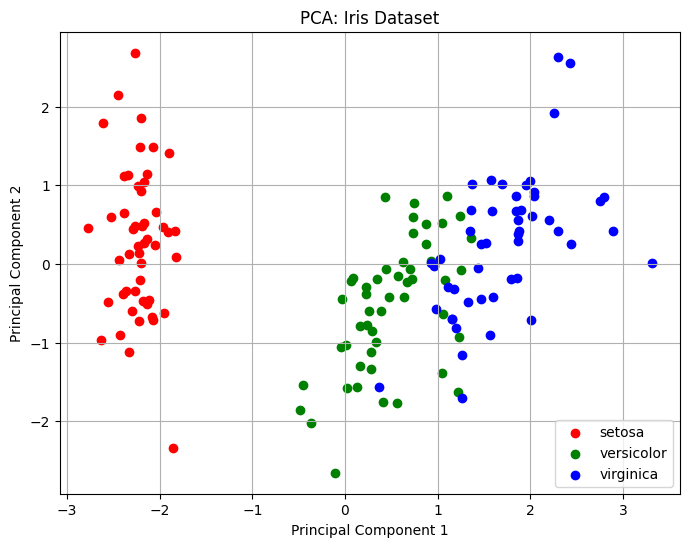

In [2]:
# Добавление меток классов
pca_result['target'] = iris.target

# Построение графика
plt.figure(figsize=(8, 6))
for target, color in zip([0, 1, 2], ['r', 'g', 'b']):
      subset = pca_result[pca_result['target'] == target]
      plt.scatter(subset['PC1'], subset['PC2'], label=iris.target_names[target], color=color)

plt.title('PCA: Iris Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid()
plt.show()

## Практика в sklearn

In [3]:
# Импорт необходимых библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, load_wine, load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Настройка визуализации
sns.set_style('whitegrid')
%matplotlib inline

### 1. Инициализация моделей

Рассмотрим базовую инициализацию `RandomForestClassifier` и `RandomForestRegressor`.

In [4]:
# Пример для классификации
rf_clf = RandomForestClassifier(
    n_estimators=100,      # Количество деревьев в лесу
    max_depth=10,          # Максимальная глубина каждого дерева
    min_samples_split=2,   # Минимальное количество объектов для разбиения узла
    criterion='gini',      # Критерий качества (gini или entropy)
    max_features='sqrt',    # Количество признаков для поиска лучшего разбиения (sqrt(m))
    random_state=42        # Фиксация случайности для воспроизводимости
)

# Пример для регрессии
rf_reg = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=2,
    criterion='squared_error', # MSE для регрессии
    max_features='sqrt',
    random_state=42
)

print("Модели инициализированы.")

Модели инициализированы.


### 2. Ключевые гиперпараметры Random Forest

1.  **`n_estimators`**: Количество деревьев в лесу. Чем больше, тем стабильнее и точнее модель, но дольше обучение. Обычно оптимальное значение находится в диапазоне 100-500.
2.  **`max_depth`**: Максимальная глубина дерева. Ограничивает рост дерева, предотвращая переобучение. Чем меньше глубина, тем более "гладкая" модель.
3.  **`min_samples_split`**: Минимальное количество объектов, необходимое для разделения внутреннего узла. Увеличение этого параметра также уменьшает переобучение.
4.  **`criterion`**: Функция для оценки качества разбиения.
    *   Для классификации: `'gini'` (коэффициент Джини) или `'entropy'` (энтропия).
    *   Для регрессии: `'squared_error'` (MSE), `'absolute_error'` (MAE).
5.  **`max_features`**: Количество признаков, которые рассматриваются для поиска лучшего разбиения в узле.
    *   `'sqrt'`: $\sqrt{m}$ (рекомендуется для классификации).
    *   `'log2'`: $\log_2(m)$.
    *   `None`: все признаки (увеличивает риск корреляции деревьев).
    *   `'auto'`: то же, что и `'sqrt'`.

**Важно**: Параметр `n_jobs`, отвечающий за количество используемых ядер процессора, не рассматривается в этом семинаре и вынесен на самостоятельное изучение.

## Сравнение моделей

c:\Users\79222\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                 Model  Accuracy  F1-score
0        Decision Tree  0.918129  0.934579
1        Random Forest  0.935673  0.948837
2  Logistic Regression  0.953216  0.963636


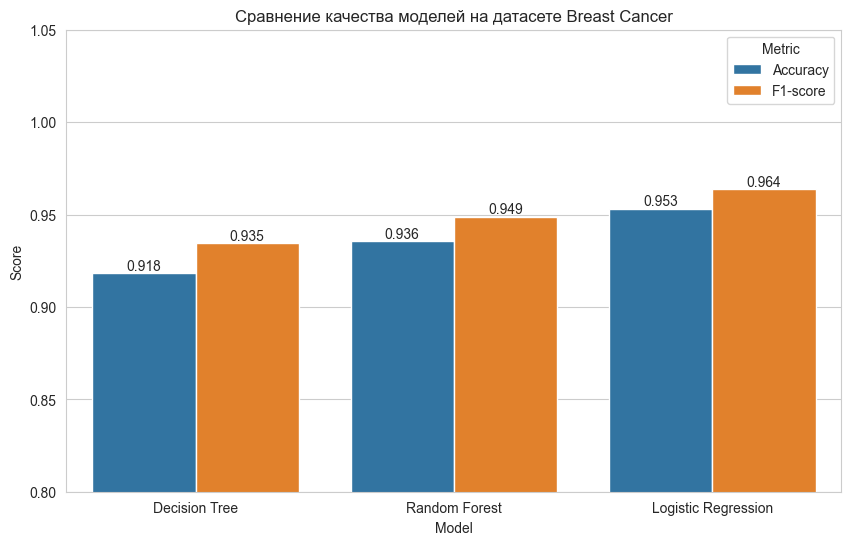

In [5]:
# Загрузка и подготовка данных (breast_cancer)
data = load_breast_cancer()
X = data.data
y = data.target

# Разделение на train и test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Инициализация моделей
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
lr = LogisticRegression(max_iter=1000, random_state=42)

# Обучение моделей
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
lr.fit(X_train, y_train)

# Предсказание
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)
y_pred_lr = lr.predict(X_test)

# Оценка качества
results = {
    'Model': ['Decision Tree', 'Random Forest', 'Logistic Regression'],
    'Accuracy': [accuracy_score(y_test, y_pred_dt),
                 accuracy_score(y_test, y_pred_rf),
                 accuracy_score(y_test, y_pred_lr)],
    'F1-score': [f1_score(y_test, y_pred_dt),
                 f1_score(y_test, y_pred_rf),
                 f1_score(y_test, y_pred_lr)]
}

df_results = pd.DataFrame(results)
print(df_results)

# Визуализация
fig, ax = plt.subplots(figsize=(10, 6))
df_results_melted = df_results.melt(id_vars='Model', var_name='Metric', value_name='Score')
sns.barplot(data=df_results_melted, x='Model', y='Score', hue='Metric', ax=ax)
ax.set_title('Сравнение качества моделей на датасете Breast Cancer')
ax.set_ylim(0.8, 1.05)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')
plt.show()

## Полноценный Pipeline

### Важные нюансы

1.  **Масштабирование (Scaling)**: Решающие деревья и, следовательно, Случайный лес, являются **инвариантными к масштабу признаков**. Они работают с порогами сравнения, которые не зависят от абсолютных величин. Поэтому `StandardScaler` или `MinMaxScaler` **не нужны** для Random Forest.
    *   *Зачем же мы его добавим в пайплайн?* Чтобы показать, как его можно включить, и подчеркнуть, что это не требуется, но в составе пайплайна для других моделей (например, LogisticRegression) он критически важен.
2.  **Пропуски в данных (Missing values)**:
    *   **"Из коробки"**: В большинстве реализаций решающих деревьев (CART) пропуски обрабатываются, но не всегда очевидным образом. Алгоритм может искать "суррогатные" разбиения или просто игнорировать объекты с пропусками в узле.
    *   **Реализация в sklearn**: `DecisionTreeClassifier` и `RandomForestClassifier` из `sklearn` **не умеют обрабатывать пропуски** (NaN). Если в данных есть пропуски, модель выдаст ошибку. Поэтому предварительная обработка (`SimpleImputer`) обязательна.

In [6]:
# Создадим пайплайн, который включает обработку пропусков и масштабирование,
# а затем обучим модель

# Создаем DataFrame с намеренно добавленными пропусками для демонстрации
X_with_nan = X.copy()
rng = np.random.RandomState(42)
for i in range(10):
    X_with_nan[rng.randint(0, X.shape[0]), rng.randint(0, X.shape[1])] = np.nan

X_train_nan, X_test_nan, y_train, y_test = train_test_split(
    X_with_nan, y, test_size=0.3, random_state=42, stratify=y
)

# Пайплайн: Imputer -> Scaler -> RandomForest
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # Заполняем пропуски медианой
    ('scaler', StandardScaler()),                  # Масштабирование (для демонстрации, хотя RF не требует)
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Обучение пайплайна
pipeline.fit(X_train_nan, y_train)

# Предсказание и оценка
y_pred_pipe = pipeline.predict(X_test_nan)
accuracy_pipe = accuracy_score(y_test, y_pred_pipe)
print(f'Точность модели с пайплайном: {accuracy_pipe:.4f}')

# Если убрать масштабирование, результат будет аналогичным (RF нечувствителен к масштабу)
pipeline_no_scaler = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])
pipeline_no_scaler.fit(X_train_nan, y_train)
y_pred_no_scaler = pipeline_no_scaler.predict(X_test_nan)
print(f'Точность модели без масштабирования: {accuracy_score(y_test, y_pred_no_scaler):.4f}')

Точность модели с пайплайном: 0.9357
Точность модели без масштабирования: 0.9357


## Задание для самостоятельного решения

### Настройка гиперпараметров для задачи регрессии

**Датасет**: `diabetes` (встроенный в `sklearn`). Это датасет для регрессии, где целевая переменная — прогрессирование диабета через год после baseline.

**Задача**:

1.  Загрузите датасет `load_diabetes()`.
2.  Разделите данные на обучающую и тестовую выборки (test_size=0.2, random_state=42).
3.  Создайте объект `RandomForestRegressor`.
4.  Используя `GridSearchCV`, подберите оптимальные гиперпараметры:
    *   `n_estimators`: [50, 100, 200]
    *   `max_depth`: [5, 10, None]
    *   `min_samples_split`: [2, 5, 10]
    *   `max_features`: ['sqrt', 'log2', None]
    *   **Важно**: Не используйте `n_jobs`. Установите `cv=3` для кросс-валидации.
5.  Обучите `GridSearchCV` на обучающей выборке.
6.  Выведите лучшие найденные параметры и лучшую оценку (используйте `neg_mean_squared_error` как scoring).
7.  Оцените качество лучшей модели на тестовой выборке (MSE и RMSE).
8.  *Бонус* (необязательно): Сравните качество с обычным `DecisionTreeRegressor` (без настройки параметров).

Про RandomForestRegressor можно почитать [здесь](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html)

In [ ]:
# Задание: Реализуйте решение здесь

# 1. Загрузка данных
# data = load_diabetes()
# X, y = ..., ...

# 2. Разделение данных
# X_train, ..., y_train, ... = ...

# 3. Инициализация модели
# rf = RandomForestRegressor(random_state=..)

# 4. Сетка параметров
# param_grid = {}

# 5. GridSearchCV (в качестве scoring используйте neg_mean_squared_error)
# grid_search = GridSearchCV(..., cv=3, verbose=1)
# grid_search.fit(..., ...)

# 6. Вывод лучших параметров
# Ваш код здесь

# 7. Оценка на тесте
# Ваш код здесь

# 8. Бонус: Сравнение с DecisionTree
# Ваш код здесь